# Agent-Based Model of Household Water Conservation Interventions

## 1. Setup

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.lines as mlines
import contextlib
from scipy.stats import shapiro
from scipy.stats import linregress
from statsmodels.stats.multitest import multipletests

# This seed makes the random sampling reproducible
# When the seed stays the same, the same agents and app adopters are selected again
Seed = 67
RandomGenerator = np.random.default_rng(Seed)

# Load the survey data.
# Put DatasetExperiment.csv in the same folder as this notebook
PathToData = "DatasetExperiment.csv"
Data = pd.read_csv(PathToData)
Data.columns = Data.columns.astype(str).str.strip()

# Number of synthetic agents. Each agent is sampled from one real survey respondent.
NumberOfAgents = 500

# The model starts in April 2026, so the first months before the intervention are visible
StartDateOfSimulation = pd.Timestamp("2026-04-01")
EndDateOfSimulation = pd.Timestamp("2030-12-31")
NumberOfWeeks = int((EndDateOfSimulation - StartDateOfSimulation).days // 7)

# The first intervention moment is July 2026.
FirstDateOfIntervention = pd.Timestamp("2026-07-01")

# p_monthly = 0.20 and p_April = 0.95, based on participation rates from Fowlie et al. (2021)
MonthlyOptIn = 0.20
YearlyOptOutApril = 0.95

# One model step is one week
DaysPerWeek = 7

# 100 L per person per day, shown as 700 L per week in the plots
# (Algemene Rekenkamer, 2025)
WaterTargetDailyPerPerson = 100
WaterTarget = WaterTargetDailyPerPerson * DaysPerWeek

def GetWeekDate(Week):
    """Turn a week number into a real calendar date."""
    return StartDateOfSimulation + pd.Timedelta(weeks=int(Week))


def IsMonthlyInterventionWeek(Week):
    """Check if this week is the first model week of a new month after July 2026."""
    if Week < 0:
        return False

    CurrentDate = GetWeekDate(Week)
    PreviousDate = GetWeekDate(Week - 1)

    if CurrentDate < FirstDateOfIntervention:
        return False

    return CurrentDate.month != PreviousDate.month

def InterventionProbabilityForWeek(Week):
    """Return the probability that an agent gets the intervention in this week."""
    if not IsMonthlyInterventionWeek(Week):
        return 0.0

    CurrentDate = GetWeekDate(Week)

    # April is treated as the high-coverage yearly tax moment.
    if CurrentDate.month == 4:
        return YearlyOptOutApril

    return MonthlyOptIn


## 2. Clean and prepare the data

The model uses six behaviours from the survey. Shower frequency, shower duration, and washing-machine frequency are behaviours where lower values mean saving more water. Turning off water, wash mode, and toilet flush button use are behaviours where higher values mean saving more water. These behaviours are the same as the behaviours used in the formula sheet to calculate weekly water use, with showering, washing-machine use, and toilet flushing as the main household water-use categories (Bakker et al., 2022a; Centraal Bureau voor de Statistiek, 2023).



In [48]:
# These behaviours should go down when people save water.
MinimiseBehaviours = ["NumberOfShowers", "ShowerDuration", "NumberOfWashing"]

# These behaviours should go up when people save water.
MaximiseBehaviours = ["Turnwateroff", "WashMode", "FlushButton"]

# The model uses these six behaviours.
AllBehaviours = MinimiseBehaviours + MaximiseBehaviours

# T1 = baseline, T2 = information, T3 = EFT.
T1 = "1"
T2 = "2"
T3 = "3"


def ColumnName(TimePoint, Behaviour):
    """The survey columns are written as for example '2:ShowerDuration'."""
    return f"{TimePoint}:{Behaviour}"


KColumns = ["k_T1", "k_T2", "k_T3"]
BehaviourColumns = [ColumnName(TimePoint, Behaviour) for TimePoint in [T1, T2, T3] for Behaviour in AllBehaviours]

# Make sure all columns needed for the model are numeric.
for Column in KColumns + BehaviourColumns:
    Data[Column] = pd.to_numeric(Data[Column], errors="coerce")

# Keep only rows that have all model variables.
Data = Data.dropna(subset=KColumns + BehaviourColumns).copy()
print(f"Number of rows retained: {len(Data)}")


# Testing if it k is normally distributed
display(pd.DataFrame({
    "Variable": ["k_T1", "k_T3"],
    "Shapiro_p": [shapiro(Data["k_T1"].dropna()).pvalue,
                  shapiro(Data["k_T3"].dropna()).pvalue]
}))

Data["LnkT1"] = np.log(Data["k_T1"])
Data["LnkT3"] = np.log(Data["k_T3"])

# It is not normally distributed
# k_T1	8.690749e-22
# k_T3	6.883706e-2

# ln(k) is used because delay discounting is skewed.
Data["LnkT1"] = np.log(Data["k_T1"])
Data["LnkT3"] = np.log(Data["k_T3"])

# Make the synthetic population by sampling real respondents with replacement.
# This keeps realistic combinations from the survey, but allows 500 agents.
SampledRows = RandomGenerator.choice(Data.index, size=NumberOfAgents, replace=True)
Agents = Data.loc[SampledRows].reset_index(drop=True)
Agents["AgentId"] = np.arange(NumberOfAgents)


Number of rows retained: 108


,Variable,Shapiro_p
0,k_T1,8.690749e-22
1,k_T3,6.883706e-21


## 3. Empirical effects from the survey

This part calculates the model input values that come from the survey: the information effect, the EFT effect, and the part of the EFT effect that is linked to delay discounting. The formula sheet uses the change between T1 and T3 to estimate the EFT effect, and it uses a simple regression to estimate how much of the intention change is statistically associated with the change in ln(k). This follows the logic of using explained variance to link psychological change to water-saving intention, while keeping it as a model assumption rather than a proven causal effect (Duan et al., 2025).

Repeated EFT is modelled with a saturating curve, because repeated EFT sessions can cumulatively reduce delay discounting while each extra session adds a smaller marginal change (Mellis et al., 2019).



In [49]:
# Changes from baseline
Data["DeltaLnk"] = Data["LnkT3"] - Data["LnkT1"]

for Behaviour in AllBehaviours:
    Data[f"DeltaEft_{Behaviour}"] = Data[ColumnName(T3, Behaviour)] - Data[ColumnName(T1, Behaviour)]
    Data[f"DeltaInfo_{Behaviour}"] = Data[ColumnName(T2, Behaviour)] - Data[ColumnName(T1, Behaviour)]


def RegressionStats(Predictor, Outcome):
    """Simple one-variable regression R² and p-value."""
    Predictor = np.asarray(Predictor, dtype=float)
    Outcome = np.asarray(Outcome, dtype=float)

    Mask = ~np.isnan(Predictor) & ~np.isnan(Outcome)
    Predictor, Outcome = Predictor[Mask], Outcome[Mask]

    if len(Predictor) < 3 or np.isclose(np.var(Predictor), 0) or np.isclose(np.var(Outcome), 0):
        return 0.0, np.nan

    Result = linregress(Predictor, Outcome)
    return Result.rvalue ** 2, Result.pvalue


# p = R² in the formula sheet; p_value = regression significance
RegressionTable = pd.DataFrame([
    {
        "Behaviour": Behaviour,
        "p": RegressionStats(Data["DeltaLnk"], Data[f"DeltaEft_{Behaviour}"])[0],
        "p_value": RegressionStats(Data["DeltaLnk"], Data[f"DeltaEft_{Behaviour}"])[1],
    }
    for Behaviour in AllBehaviours
])

RegressionTable["p_holm"] = multipletests(
    RegressionTable["p_value"],
    alpha=0.05,
    method="holm"
)[1]

RegressionTable["Significant_holm"] = RegressionTable["p_holm"] < 0.05

display(RegressionTable)


# EFT reduction in ln(k), based on a saturating curve
DeltaEFT = 2.8
LambdaEFT = 0.55

def LnkAfterSession(LnkStart, Session):
    return LnkStart - DeltaEFT * (1 - np.exp(-LambdaEFT * Session))


CalibrationLnkReduction = DeltaEFT * (1 - np.exp(-LambdaEFT))
ObservedLnkReduction = (Data["LnkT1"] - Data["LnkT3"]).mean()

Gamma = {}
ResidualEft = {}
MeanInfoEffect = {}

for Behaviour in AllBehaviours:
    PValue = RegressionTable.loc[RegressionTable["Behaviour"] == Behaviour, "p"].iloc[0]
    MeanEftChange = Data[f"DeltaEft_{Behaviour}"].mean()

    Gamma[Behaviour] = PValue * MeanEftChange / CalibrationLnkReduction
    ResidualEft[Behaviour] = (1 - PValue) * MeanEftChange
    MeanInfoEffect[Behaviour] = Data[f"DeltaInfo_{Behaviour}"].mean()


GammaTable = pd.DataFrame({
    "Behaviour": AllBehaviours,
    "Gamma": [Gamma[Behaviour] for Behaviour in AllBehaviours],
    "Observed lnk reduction T1-T3": ObservedLnkReduction,
    "Calibration lnk reduction session 1": CalibrationLnkReduction,
})

display(GammaTable)

,Behaviour,p,p_value,p_holm,Significant_holm
0,NumberOfShowers,0.032007,0.063945,0.172951,False
1,ShowerDuration,0.099113,0.000905,0.004526,True
2,NumberOfWashing,0.003492,0.543524,0.543524,False
3,Turnwateroff,0.033581,0.057650,0.172951,False
4,WashMode,0.066184,0.007192,0.028767,True
5,FlushButton,0.176234,0.000006,0.000037,True


,Behaviour,Gamma,Observed lnk reduction T1-T3,Calibration lnk reduction session 1
0,NumberOfShowers,-0.013010,-0.042665,1.184541
1,ShowerDuration,-0.210730,-0.042665,1.184541
2,NumberOfWashing,-0.001065,-0.042665,1.184541
3,Turnwateroff,0.029399,-0.042665,1.184541
4,WashMode,0.036214,-0.042665,1.184541
5,FlushButton,0.075767,-0.042665,1.184541


## 4. Intention updates and decay

Agents cannot improve forever. Each behaviour has a target from the formula sheet. After an intervention, the effect is scaled by how far the agent still is from that target. This prevents the model from pushing agents far beyond the behavioural target.

After the intervention effect is added, intention slowly decays back toward baseline. The starting decay value is based on water-saving intervention decay estimates from Duan et al. (2025). The EFT decay is treated as more durable because EFT uses vivid future-event construction, which is connected to constructive memory processes (Schacter, 2012). Repetition is also used to make the decay slower after more sessions, because repeated study, repeated retrieval, and memory reactivation can reduce forgetting over time (MacLeod et al., 2018; Rahman et al., 2021; Wang & Yang, 2024).



In [50]:
# Formula sheet Appendix L: target values for each behaviour.
BehaviourTargets = {
    "NumberOfShowers": 2.0,
    "ShowerDuration": 5.0,
    "NumberOfWashing": 1.0,
    "Turnwateroff": 5.0,
    "WashMode": 5.0,
    "FlushButton": 5.0,
}


def PersonalTarget(Behaviour, BaselineValues):
    """Give each agent a target, but do not make agents worse if they already passed it."""
    BaselineValues = np.asarray(BaselineValues, dtype=float)
    Target = BehaviourTargets[Behaviour]

    if Behaviour in MinimiseBehaviours:
        return np.where(BaselineValues <= Target, BaselineValues, Target)

    return np.where(BaselineValues >= Target, BaselineValues, Target)


def ScaledResidual(Behaviour, CurrentValues, BaselineValues, RawEffect):
    """Scale an intervention effect by the remaining distance to the target."""
    CurrentValues = np.asarray(CurrentValues, dtype=float)
    BaselineValues = np.asarray(BaselineValues, dtype=float)
    TargetValues = PersonalTarget(Behaviour, BaselineValues)

    InitialGap = TargetValues - BaselineValues
    Scale = np.zeros_like(CurrentValues, dtype=float)
    ValidAgents = np.abs(InitialGap) > 1e-12

    Scale[ValidAgents] = (TargetValues[ValidAgents] - CurrentValues[ValidAgents]) / InitialGap[ValidAgents]
    Scale = np.clip(Scale, 0, 1)

    return RawEffect * Scale


def ClipIntentions(Intentions):
    """Keep intention values inside possible survey ranges."""
    ClippedIntentions = Intentions.copy()

    for Behaviour in MinimiseBehaviours:
        ClippedIntentions[Behaviour] = np.maximum(0, np.asarray(ClippedIntentions[Behaviour], dtype=float))

    for Behaviour in MaximiseBehaviours:
        ClippedIntentions[Behaviour] = np.clip(np.asarray(ClippedIntentions[Behaviour], dtype=float), 1, 5)

    return ClippedIntentions


def ApplyEft(Intentions, BaselineIntentions, LnkStart, SessionCount):
    """Apply one EFT session: residual EFT effect plus the ln(k) pathway."""
    NewIntentions = Intentions.copy()
    PreviousLnk = LnkAfterSession(LnkStart, SessionCount - 1)
    CurrentLnk = LnkAfterSession(LnkStart, SessionCount)
    LnkDrop = PreviousLnk - CurrentLnk

    for Behaviour in AllBehaviours:
        ResidualChange = ScaledResidual(
            Behaviour,
            NewIntentions[Behaviour],
            BaselineIntentions[Behaviour],
            ResidualEft[Behaviour],
        )
        NewIntentions[Behaviour] = NewIntentions[Behaviour] + ResidualChange + Gamma[Behaviour] * LnkDrop

    return ClipIntentions(NewIntentions)


def ApplyInfo(Intentions, BaselineIntentions):
    """Apply the information intervention. There is no ln(k) update here."""
    NewIntentions = Intentions.copy()

    for Behaviour in AllBehaviours:
        InfoChange = ScaledResidual(
            Behaviour,
            NewIntentions[Behaviour],
            BaselineIntentions[Behaviour],
            MeanInfoEffect[Behaviour],
        )
        NewIntentions[Behaviour] = NewIntentions[Behaviour] + InfoChange

    return ClipIntentions(NewIntentions)


# Decay values follow Duan et al. (2025), with the EFT memory assumption based on Schacter (2012).
# EFT starts with 25 days and can grow to 180 days.
Tau0Eft = 25
TauMaxEft = 180
MuEft = 0.4

# Information decay uses lower values than EFT.
Tau0Info = 13
TauMaxInfo = 30
MuInfo = 0.4


def TauEft(SessionCount):
    """Decay constant for EFT. More sessions means the effect lasts longer."""
    return TauMaxEft - (TauMaxEft - Tau0Eft) * np.exp(-MuEft * SessionCount)


def TauInfo(SessionCount):
    """Decay constant for information. This effect fades faster than EFT."""
    return TauMaxInfo - (TauMaxInfo - Tau0Info) * np.exp(-MuInfo * SessionCount)


def Decay(Intentions, BaselineIntentions, Tau):
    """Move intentions one week back toward baseline."""
    DecayedIntentions = Intentions.copy()
    RemainingFraction = np.exp(-DaysPerWeek / Tau)

    for Behaviour in AllBehaviours:
        BaselineValues = np.asarray(BaselineIntentions[Behaviour], dtype=float)
        CurrentValues = np.asarray(Intentions[Behaviour], dtype=float)
        DecayedIntentions[Behaviour] = BaselineValues + (CurrentValues - BaselineValues) * RemainingFraction

    return ClipIntentions(DecayedIntentions)


## 5. Weekly water use

The model turns intentions into weekly household water use for showering, washing-machine use, and toilet flushing. These are the three biggest household drinking-water categories in the formula sheet (Bakker et al., 2022a; Centraal Bureau voor de Statistiek, 2023).

Showerhead flow rates come from Milieu Centraal (2023). Washing-machine water use comes from the CBS daily water-use overview, and the eco-mode saving comes from Vitens (2024). Toilet flush frequency and flush volumes come from the Dutch Watergebruik Thuis estimates (Bakker et al., 2022a, 2022b). The rainwater and greywater correction is based on the average saving estimates used in the formula sheet from López Zavala et al. (2016) and Rosa and Ghisi (2021).

The final step applies the intention-behaviour gap. Only part of stated intention is translated into actual behaviour, using the 0.50 factor from Sheeran and Gollwitzer (2015).



In [51]:
# Showerhead values come from the formula sheet source list (Milieu Centraal).
StandardShowerFlow = 7.3
SavingShowerFlow = 4.0
RainShowerFlow = 10.22

# Vitens: assumed water-off duration while showering.
WaterOffDuration = 6.0

# Washing-machine values: CBS and Vitens.
WashingMachineLitres = 49.0
EcoModeSaving = 0.40

# Toilet values: Bakker et al.
WeeklyToiletFlushes = 46.2
FullFlushLitres = 6.7
SmallFlushLitres = 3.7

# Rainwater/greywater correction
GreywaterCorrection = 0.5867

def FlowRate(ShowerheadText):
    """Choose the shower flow rate from the showerhead answer."""
    Text = str(ShowerheadText).lower()

    if "saving" in Text or "water-saving" in Text:
        return SavingShowerFlow

    if "rain" in Text:
        return RainShowerFlow

    return StandardShowerFlow

def YesBinary(Value):
    """Turn yes/no answers into 1 or 0."""
    return 1.0 if str(Value).strip().lower() in ["yes", "ja", "true", "1"] else 0.0

def LikertProbability(Value):
    """Turn a 1-5 scale into 0-1, so it can be used like a probability."""
    return np.clip((np.asarray(Value, dtype=float) - 1) / 4, 0, 1)

Agents["FlowRate"] = Agents["Showerhead"].apply(FlowRate)
Agents["GreywaterBinary"] = Agents["Greywater"].apply(YesBinary)

def WeeklyWater(Intentions):
    """Calculate weekly water use for every agent."""
    NumberOfShowers = np.maximum(0, np.asarray(Intentions["NumberOfShowers"], dtype=float))
    ShowerDuration = np.maximum(0, np.asarray(Intentions["ShowerDuration"], dtype=float))
    TurnWaterOff = LikertProbability(np.asarray(Intentions["Turnwateroff"], dtype=float))
    ShowerFlow = Agents["FlowRate"].to_numpy(float)

    ShowerWater = np.maximum(
        1,
        NumberOfShowers * ShowerDuration * ShowerFlow - TurnWaterOff * WaterOffDuration * ShowerFlow,
    )

    NumberOfWashes = np.maximum(0, np.asarray(Intentions["NumberOfWashing"], dtype=float))
    EcoModeUse = LikertProbability(np.asarray(Intentions["WashMode"], dtype=float))
    WashingWater = NumberOfWashes * WashingMachineLitres * (1 - EcoModeSaving * EcoModeUse)

    SmallFlushUse = LikertProbability(np.asarray(Intentions["FlushButton"], dtype=float))
    GreywaterFactor = np.where(Agents["GreywaterBinary"].to_numpy(float) == 1, GreywaterCorrection, 1.0)

    ToiletWater = WeeklyToiletFlushes * (SmallFlushUse * SmallFlushLitres + (1 - SmallFlushUse) * FullFlushLitres) * GreywaterFactor

    return ShowerWater + WashingWater + ToiletWater

# AlphaIB = 0.50 follows the intention-behaviour gap estimate from Sheeran and Gollwitzer (2015).
# Only half of an intention change becomes real behaviour change.
AlphaIB = 0.50

def IntentionBehaviourGap(WeeklyWaterFromIntentions, BaselineWater):
    """Apply the intention-behaviour gap to weekly water use."""
    return BaselineWater + AlphaIB * (WeeklyWaterFromIntentions - BaselineWater)


BaselineIntentions = pd.DataFrame({
    Behaviour: Agents[ColumnName(T1, Behaviour)].to_numpy(float)
    for Behaviour in AllBehaviours
})

BaselineWater = WeeklyWater(BaselineIntentions)

print(f"Mean baseline weekly water use: {BaselineWater.mean():.1f} L/week")
print(f"Weekly target reference: {WaterTarget:.0f} L/week")


Mean baseline weekly water use: 820.2 L/week
Weekly target reference: 700 L/week


## 6. Social comparison

Only agents who adopt the smart-meter app receive social-comparison feedback. The app adoption probability is 0.78, based on Dutch public attitudes toward digital water meters (Koop et al., 2021).

The norm is the median water use among app adopters. Social-comparison strength is calibrated from water conservation field experiments (Brent et al., 2015; Ferraro & Price, 2013). The model also includes non-responders, because many households in a smart-meter water-feedback study showed no meaningful reduction after feedback (Otaki et al., 2024), and other work also reports heterogeneous responses to water eco-feedback (Ramli et al., 2021).

The injunctive scenario blocks the upward boomerang effect. This follows social-norm research showing that descriptive comparison can push low users upward, while injunctive feedback can signal that low use is desirable (Schultz et al., 2007; Schultz et al., 2019).



In [52]:
# Formula sheet Appendix T.
# DeltaSocial = 0.049 over 4 weeks, calibrated from Ferraro and Price (2013) and Brent et al. (2015).
DeltaSocial = 0.049
SocialCalibrationWeeks = 4
Phi = 1 - (1 - DeltaSocial) ** (1 / SocialCalibrationWeeks)

# Koop et al. (2021): 78% app adoption.
PAdopt = 0.78
AdoptionGenerator = np.random.default_rng(Seed + 1)
AppAdopter = AdoptionGenerator.random(NumberOfAgents) < PAdopt

# Otaki et al. (2024): 56.1% non-responders.
NonResponderShare = 0.561
MeanResponder = 1 / (1 - NonResponderShare)
SdResponder = 0.5


def DrawTruncatedNormal(Mean, Sd, Lower, Upper, Size, Generator):
    """Draw positive normal values without using scipy."""
    Values = np.empty(Size, dtype=float)
    Filled = 0

    while Filled < Size:
        Draw = Generator.normal(Mean, Sd, size=max(1000, 2 * (Size - Filled)))
        Draw = Draw[(Draw >= Lower) & (Draw <= Upper)]
        NumberToTake = min(Size - Filled, Draw.size)

        if NumberToTake > 0:
            Values[Filled:Filled + NumberToTake] = Draw[:NumberToTake]
            Filled += NumberToTake

    return Values


ResponderGenerator = np.random.default_rng(Seed + 2)
NonResponderGenerator = np.random.default_rng(Seed + 3)

ResponderValues = DrawTruncatedNormal(MeanResponder, SdResponder, 0.0, np.inf, NumberOfAgents, ResponderGenerator)
IsNonResponder = NonResponderGenerator.random(NumberOfAgents) < NonResponderShare
Responsiveness = np.where(IsNonResponder, 0.0, ResponderValues)
AgentPhi = np.where(AppAdopter, Responsiveness * Phi, 0.0)

RhoBoomerang = 1
RhoInjunctive = 0


def SocialComparison(WaterUse, PhiValues, Rho=RhoBoomerang, Adopters=None):
    """Apply one weekly social-comparison update."""
    WaterUse = np.asarray(WaterUse, dtype=float)
    PhiValues = np.asarray(PhiValues, dtype=float)

    if Adopters is None:
        Adopters = PhiValues > 0
    else:
        Adopters = np.asarray(Adopters, dtype=bool)

    NewWaterUse = WaterUse.copy()

    if not Adopters.any():
        return NewWaterUse

    Norm = np.median(WaterUse[Adopters])
    Difference = WaterUse - Norm

    # Vectorised version of the formula sheet update:
    # high users move down, low users only move up when rho is 1.
    Adjustment = np.where(
        Difference > 0,
        PhiValues * Difference,
        np.where(Difference < 0, Rho * PhiValues * Difference, 0.0),
    )

    NewWaterUse[Adopters] = WaterUse[Adopters] - Adjustment[Adopters]
    return np.maximum(0, NewWaterUse)


print(f"App adopters: {AppAdopter.sum()} / {NumberOfAgents} ({AppAdopter.mean() * 100:.1f}%)")
print(f"Social comparison calibrated: phi={Phi:.4f}, p_adopt={PAdopt}, non-responder share={NonResponderShare}")


App adopters: 379 / 500 (75.8%)
Social comparison calibrated: phi=0.0125, p_adopt=0.78, non-responder share=0.561


## 7. Run the ABM

The model is run for the baseline, information, and EFT conditions. The baseline condition has no intervention effect. The information condition changes intention but does not change ln(k), because experimental reviews find that delay-discounting reductions are linked to interventions that directly target discounting rather than simple information alone (Rung & Madden, 2018). The EFT condition updates ln(k), intention, behaviour, and then social comparison.

Noise is added only to the observed water-use output, so the intervention pathway itself is not changed by the noise.



In [53]:
# Small weekly household variation in observed water use.
SigmaNoise = 8.0
PhiAr = 0.50


def RunModel(Condition, KeepAgents=False, PhiValues=AgentPhi, AdoptersMask=AppAdopter, RhoValue=RhoBoomerang):
    """Run the ABM for one condition and one social-feedback setting."""
    Intentions = {Behaviour: BaselineIntentions[Behaviour].to_numpy(float).copy() for Behaviour in AllBehaviours}
    EftSessionCount = np.zeros(NumberOfAgents, dtype=int)
    InfoSessionCount = np.zeros(NumberOfAgents, dtype=int)

    WeeklyRecords = []
    AgentRecords = []

    SocialWaterState = None
    PreviousActualWater = None

    SeedOffset = {"baseline": 101, "information": 202, "eft": 303}.get(Condition, 999)
    InterventionGenerator = np.random.default_rng(Seed + 50_000 + SeedOffset)
    NoiseGenerator = np.random.default_rng(Seed + SeedOffset)

    NoiseState = np.zeros(NumberOfAgents)
    NoiseInnovationSd = SigmaNoise * np.sqrt(1 - PhiAr ** 2)

    for Week in range(NumberOfWeeks + 1):
        WeekDate = GetWeekDate(Week)
        InterventionProbability = InterventionProbabilityForWeek(Week)
        IntervenedThisWeek = np.zeros(NumberOfAgents, dtype=bool)

        if InterventionProbability > 0 and Condition in ["information", "eft"]:
            IntervenedThisWeek = InterventionGenerator.random(NumberOfAgents) < InterventionProbability

            if Condition == "information":
                InfoSessionCount[IntervenedThisWeek] += 1
                UpdatedIntentions = ApplyInfo(Intentions, BaselineIntentions)

            else:
                EftSessionCount[IntervenedThisWeek] += 1
                UpdatedIntentions = ApplyEft(
                    Intentions,
                    BaselineIntentions,
                    LnkStart=Agents["LnkT1"].to_numpy(float),
                    SessionCount=np.maximum(EftSessionCount, 1),
                )

            for Behaviour in AllBehaviours:
                Intentions[Behaviour] = np.where(IntervenedThisWeek, UpdatedIntentions[Behaviour], Intentions[Behaviour])

        WeeklyWaterFromIntentions = WeeklyWater(Intentions)
        ActualWater = IntentionBehaviourGap(WeeklyWaterFromIntentions, BaselineWater)

        # Social comparison works as a carried-forward water-use state.
        if Week == 0:
            SocialWaterState = ActualWater.copy()
            PreviousActualWater = ActualWater.copy()
        else:
            IndividualChange = ActualWater - PreviousActualWater
            SocialWaterState = np.clip(SocialWaterState + IndividualChange, 0, None)
            PreviousActualWater = ActualWater.copy()

        SocialWater = SocialComparison(SocialWaterState, PhiValues, Rho=RhoValue, Adopters=AdoptersMask)
        SocialWaterState = SocialWater.copy()

        # AR(1) noise. This only makes the observed line more realistic.
        NoiseState = PhiAr * NoiseState + NoiseGenerator.normal(0, NoiseInnovationSd, size=NumberOfAgents)
        ObservedWater = np.clip(SocialWater + NoiseState, 0, None)

        WeeklyRecords.append({
            "week": Week,
            "date": WeekDate,
            "condition": Condition,
            "mean_water": ObservedWater.mean(),
            "distance": ObservedWater.mean() - WaterTarget,
            "n_intervened": int(IntervenedThisWeek.sum()),
            "intervention_probability": float(InterventionProbability),
            "eft_session": int(EftSessionCount.max()),
            "info_session": int(InfoSessionCount.max()),
            "mean_noise": float(NoiseState.mean()),
            "sd_noise": float(NoiseState.std()),
        })

        if KeepAgents:
            for AgentIndex, Water in enumerate(ObservedWater):
                AgentRecords.append({
                    "week": Week,
                    "date": WeekDate,
                    "condition": Condition,
                    "agent_id": AgentIndex,
                    "water_use": Water,
                    "water_use_without_noise": float(SocialWater[AgentIndex]),
                    "noise_i": float(NoiseState[AgentIndex]),
                    "intervened_this_week": bool(IntervenedThisWeek[AgentIndex]),
                    "has_app": bool(AdoptersMask[AgentIndex]),
                    "phi_agent": float(PhiValues[AgentIndex]),
                })

        if Condition == "information":
            Intentions = Decay(Intentions, BaselineIntentions, TauInfo(InfoSessionCount))
        elif Condition == "eft":
            Intentions = Decay(Intentions, BaselineIntentions, TauEft(EftSessionCount))
        else:
            Intentions = {Behaviour: BaselineIntentions[Behaviour].to_numpy(float).copy() for Behaviour in AllBehaviours}

    MeanResults = pd.DataFrame(WeeklyRecords)

    if KeepAgents:
        return MeanResults, pd.DataFrame(AgentRecords)

    return MeanResults


SocialScenarios = {
    "No comparative feedback": {
        "phi": np.zeros(NumberOfAgents),
        "rho": RhoBoomerang,
        "adopters": np.zeros(NumberOfAgents, dtype=bool),
    },
    "Comparative feedback": {
        "phi": AgentPhi.copy(),
        "rho": RhoBoomerang,
        "adopters": AppAdopter.copy(),
    },
    "Comparative feedback + injunctive": {
        "phi": AgentPhi.copy(),
        "rho": RhoInjunctive,
        "adopters": AppAdopter.copy(),
    },
}

ConditionOrder = ["baseline", "information", "eft"]
ScenarioOrder = ["No comparative feedback", "Comparative feedback", "Comparative feedback + injunctive"]

ScenarioResults = {}
AgentFrames = []

print("Running social scenario analysis...")
for ScenarioName in ScenarioOrder:
    Settings = SocialScenarios[ScenarioName]

    for Condition in ConditionOrder:
        MeanResults, AgentResults = RunModel(
            Condition,
            KeepAgents=True,
            PhiValues=Settings["phi"],
            AdoptersMask=Settings["adopters"],
            RhoValue=Settings["rho"],
        )
        MeanResults["scenario"] = ScenarioName
        AgentResults["scenario"] = ScenarioName
        AgentResults["rho"] = Settings["rho"]

        ScenarioResults[(ScenarioName, Condition)] = MeanResults
        AgentFrames.append(AgentResults)

    print(f"  done: {ScenarioName}")

SocialAgentResults = pd.concat(AgentFrames, ignore_index=True)
print("Done.")


Running social scenario analysis...
  done: No comparative feedback
  done: Comparative feedback
  done: Comparative feedback + injunctive
Done.


## 8. Results plots

The first plot shows a random group of agents under EFT, so it is possible to see that agents do not all respond in the same way. The second plot shows the average results for all conditions and all social-feedback scenarios. The target line is 700 L per week, which is 100 L per person per day over seven days and follows the target used in the formula sheet (Algemene Rekenkamer, 2025).

The table below the second plot uses the full year 2030, so it matches the final-year outcome used in the thesis results.



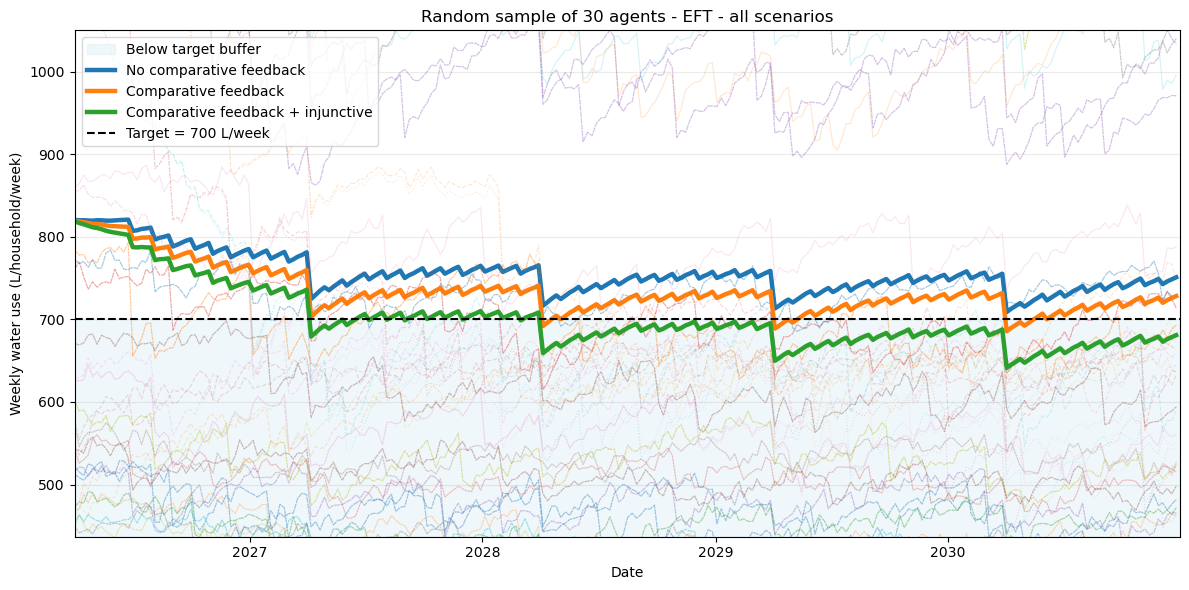

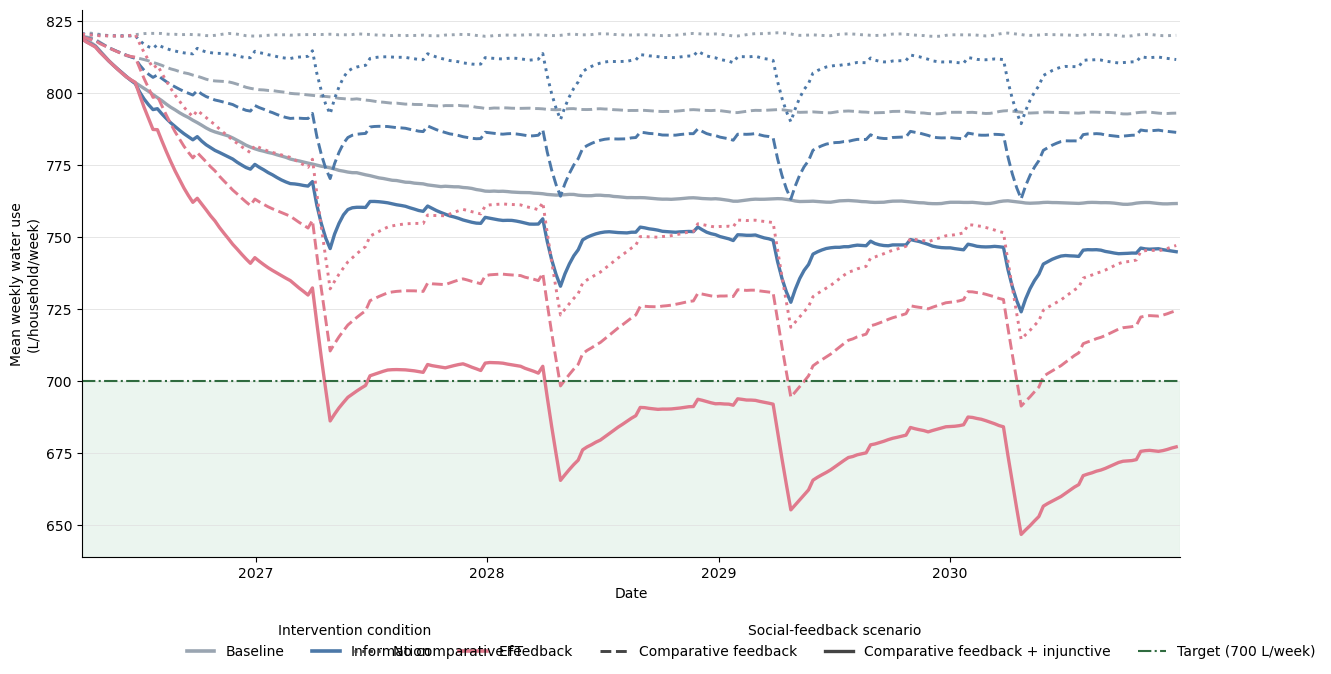

Mean weekly water use in 2030:


,Scenario,Condition,Mean 2030 water use (L/week),Target reached
0,No comparative feedback,Baseline,820.2,No
1,No comparative feedback,Information,808.8,No
2,No comparative feedback,EFT,739.2,No
3,Comparative feedback,Baseline,793.2,No
4,Comparative feedback,Information,782.9,No
5,Comparative feedback,EFT,716.3,No
6,Comparative feedback + injunctive,Baseline,761.8,No
7,Comparative feedback + injunctive,Information,743.0,No
8,Comparative feedback + injunctive,EFT,670.8,Yes


In [54]:
# Plot a sample of agents, so individual differences are visible.
ConditionForPlot = "eft"
NumberOfPlottedAgents = 30
SampleAgentIds = SocialAgentResults["agent_id"].drop_duplicates().sample(NumberOfPlottedAgents, random_state=42).tolist()

ScenarioColors = {
    "No comparative feedback": "tab:blue",
    "Comparative feedback": "tab:orange",
    "Comparative feedback + injunctive": "tab:green",
}
ScenarioLineStyles = {
    "No comparative feedback": "-",
    "Comparative feedback": "--",
    "Comparative feedback + injunctive": ":",
}

Figure, Axis = plt.subplots(figsize=(12, 6))

SubsetAll = SocialAgentResults[
    (SocialAgentResults["condition"] == ConditionForPlot)
    & (SocialAgentResults["agent_id"].isin(SampleAgentIds))
]
YMin = max(0, min(SubsetAll["water_use"].quantile(0.2), WaterTarget - 250))
YMax = max(SubsetAll["water_use"].quantile(0.6), WaterTarget + 350)

Axis.axhspan(YMin, WaterTarget, color="lightblue", alpha=0.18, label="Below target buffer")

for ScenarioName in ScenarioOrder:
    ScenarioData = SocialAgentResults[
        (SocialAgentResults["scenario"] == ScenarioName)
        & (SocialAgentResults["condition"] == ConditionForPlot)
    ]

    for AgentId in SampleAgentIds:
        AgentData = ScenarioData[ScenarioData["agent_id"] == AgentId]
        Axis.plot(
            AgentData["date"],
            AgentData["water_use"],
            linestyle=ScenarioLineStyles[ScenarioName],
            alpha=0.18,
            linewidth=0.85,
        )

    MeanLine = ScenarioData.groupby("date")["water_use"].mean().reset_index()
    Axis.plot(
        MeanLine["date"],
        MeanLine["water_use"],
        color=ScenarioColors[ScenarioName],
        linewidth=3.2,
        label=ScenarioName,
    )

Axis.axhline(WaterTarget, color="black", linestyle="--", linewidth=1.5, label=f"Target = {WaterTarget:.0f} L/week")
Axis.set_ylim(YMin, YMax)
Axis.set_xlim(StartDateOfSimulation, EndDateOfSimulation)
Axis.xaxis.set_major_locator(mdates.YearLocator())
Axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
Axis.set_xlabel("Date")
Axis.set_ylabel("Weekly water use (L/household/week)")
Axis.set_title(f"Random sample of {NumberOfPlottedAgents} agents - {ConditionForPlot.upper()} - all scenarios")
Axis.grid(axis="y", alpha=0.25)
Axis.legend(frameon=True)
plt.tight_layout()
plt.savefig("random_agents_all_scenarios.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# Main overview plot.
ConditionColors = {"baseline": "#9AA5B1", "information": "#4C78A8", "eft": "#E07A8D"}
ConditionLabels = {"baseline": "Baseline", "information": "Information", "eft": "EFT"}
ScenarioStyles = {
    "No comparative feedback": {"linestyle": ":", "linewidth": 2.1, "label": "No comparative feedback"},
    "Comparative feedback": {"linestyle": "--", "linewidth": 2.1, "label": "Comparative feedback"},
    "Comparative feedback + injunctive": {"linestyle": "-", "linewidth": 2.4, "label": "Comparative feedback + injunctive"},
}

AllYValues = []
for ScenarioName in ScenarioOrder:
    for Condition in ConditionOrder:
        SmoothedWater = ScenarioResults[(ScenarioName, Condition)]["mean_water"].rolling(4, min_periods=1).mean()
        AllYValues.extend(SmoothedWater.tolist())

YMinPlot = min(AllYValues) - 8
YMaxPlot = max(AllYValues) + 8

Figure, Axis = plt.subplots(figsize=(12, 6.9))
Axis.axhspan(YMinPlot, WaterTarget, color="#A8D5BA", alpha=0.22, zorder=0)

for Condition in ConditionOrder:
    for ScenarioName in ScenarioOrder:
        DataForLine = ScenarioResults[(ScenarioName, Condition)]
        SmoothedWater = DataForLine["mean_water"].rolling(4, min_periods=1).mean()
        Axis.plot(
            DataForLine["date"],
            SmoothedWater,
            color=ConditionColors[Condition],
            linestyle=ScenarioStyles[ScenarioName]["linestyle"],
            linewidth=ScenarioStyles[ScenarioName]["linewidth"],
        )

Axis.axhline(WaterTarget, color="#2F6B3F", linewidth=1.5, linestyle="-.")
Axis.set_xlabel("Date")
Axis.set_ylabel("Mean weekly water use\n(L/household/week)")
Axis.set_xlim(StartDateOfSimulation, EndDateOfSimulation)
Axis.set_ylim(YMinPlot, YMaxPlot)
Axis.xaxis.set_major_locator(mdates.YearLocator())
Axis.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
Axis.grid(axis="y", color="#E3E3E3", linewidth=0.7, alpha=0.9)
Axis.spines["top"].set_visible(False)
Axis.spines["right"].set_visible(False)

ConditionHandles = [
    mlines.Line2D([], [], color=ConditionColors[Condition], linewidth=2.6, label=ConditionLabels[Condition])
    for Condition in ConditionOrder
]
ScenarioHandles = [
    mlines.Line2D([], [], color="#444444", linewidth=ScenarioStyles[ScenarioName]["linewidth"], linestyle=ScenarioStyles[ScenarioName]["linestyle"], label=ScenarioStyles[ScenarioName]["label"])
    for ScenarioName in ScenarioOrder
]
TargetHandle = mlines.Line2D([], [], color="#2F6B3F", linewidth=1.5, linestyle="-.", label=f"Target ({WaterTarget:.0f} L/week)")

Figure.legend(handles=ConditionHandles, title="Intervention condition", loc="lower center", bbox_to_anchor=(0.30, 0.02), ncol=3, frameon=False)
Figure.legend(handles=ScenarioHandles + [TargetHandle], title="Social-feedback scenario", loc="lower center", bbox_to_anchor=(0.70, 0.02), ncol=4, frameon=False)

plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()

# Results table for the full year 2030.
ResultRows = []
for ScenarioName in ScenarioOrder:
    for Condition in ConditionOrder:
        DataForTable = ScenarioResults[(ScenarioName, Condition)]
        Data2030 = DataForTable[DataForTable["date"].dt.year == 2030]
        Mean2030 = Data2030["mean_water"].mean()

        ResultRows.append({
            "Scenario": ScenarioName,
            "Condition": ConditionLabels[Condition],
            "Mean 2030 water use (L/week)": round(Mean2030, 1),
            "Target reached": "Yes" if Mean2030 < WaterTarget else "No",
        })

SimpleResults = pd.DataFrame(ResultRows)
print("Mean weekly water use in 2030:")
display(SimpleResults)


## 9. Sensitivity analysis

The sensitivity analysis tests low, middle, and high values for each parameter. The outcome is the mean weekly water use over the final 52 weeks of the simulation, which represents the year 2030. This matches the formula sheet and avoids mixing old window lengths with the final-year outcome.

The tested parameters are based on the same parameter groups as the formula sheet: household water-use assumptions, intervention participation, decay parameters, intention-behaviour translation, app adoption, and social-feedback response (Bakker et al., 2022a, 2022b; Brent et al., 2015; Duan et al., 2025; Ferraro & Price, 2013; Fowlie et al., 2021; Koop et al., 2021; Sheeran & Gollwitzer, 2015).



In [ ]:
FinalPointCondition = "eft"
FinalWindowWeeks = 52
SensitivityScenarios = ScenarioOrder


@contextlib.contextmanager
def TemporaryGlobals(**Patch):
    """Temporarily change model values, then put the old values back."""
    OldValues = {Name: globals()[Name] for Name in Patch}

    try:
        globals().update(Patch)
        yield
    finally:
        globals().update(OldValues)


def EndpointMetric(Condition, PhiValues, AdoptersMask, RhoValue):
    """Run the model once and return the final-window water use."""
    Output = RunModel(Condition, KeepAgents=False, PhiValues=PhiValues, AdoptersMask=AdoptersMask, RhoValue=RhoValue)
    LastWeeks = Output.tail(FinalWindowWeeks)
    MeanWater = float(LastWeeks["mean_water"].mean())

    return {
        "endpoint_mean_water": MeanWater,
        "endpoint_sd": float(LastWeeks["mean_water"].std()),
        "endpoint_min": float(LastWeeks["mean_water"].min()),
        "endpoint_max": float(LastWeeks["mean_water"].max()),
        "distance_to_target": MeanWater - WaterTarget,
    }


def RecalculateBaselineWater(Patch):
    """Patch water-use parameters and also update baseline water use."""
    OldValues = {Name: globals()[Name] for Name in Patch}
    globals().update(Patch)

    if any(Name in Patch for Name in ["StandardShowerFlow", "SavingShowerFlow", "RainShowerFlow"]):
        Agents["FlowRate"] = Agents["Showerhead"].apply(FlowRate)

    NewBaselineWater = WeeklyWater(BaselineIntentions)

    globals().update(OldValues)
    Agents["FlowRate"] = Agents["Showerhead"].apply(FlowRate)

    FullPatch = dict(Patch)
    FullPatch["BaselineWater"] = NewBaselineWater
    return FullPatch


def CurrentSocialSettings(ScenarioName):
    Settings = SocialScenarios[ScenarioName]
    return Settings["phi"].copy(), Settings["adopters"].copy(), float(Settings["rho"])


def SocialKeepCurrent(Value, ScenarioName):
    return CurrentSocialSettings(ScenarioName)


def SocialFeedbackMultiplier(Value, ScenarioName):
    PhiValues, Adopters, RhoValue = CurrentSocialSettings(ScenarioName)

    if ScenarioName == "No comparative feedback":
        return np.zeros(NumberOfAgents), np.zeros(NumberOfAgents, dtype=bool), RhoValue

    return PhiValues * Value, Adopters, RhoValue


AdoptionDrawsSensitivity = np.random.default_rng(Seed + 900).random(NumberOfAgents)


def SocialAppAdoption(Value, ScenarioName):
    PhiValues, Adopters, RhoValue = CurrentSocialSettings(ScenarioName)

    if ScenarioName == "No comparative feedback":
        return np.zeros(NumberOfAgents), np.zeros(NumberOfAgents, dtype=bool), RhoValue

    NewAdopters = AdoptionDrawsSensitivity < Value
    NewPhi = np.where(NewAdopters, Responsiveness * Phi, 0.0)
    return NewPhi, NewAdopters, RhoValue


def MakeResponsiveness(NonResponderValue=None, SdValue=None):
    NonResponderValue = NonResponderShare if NonResponderValue is None else NonResponderValue
    SdValue = SdResponder if SdValue is None else SdValue

    TemporaryResponders = DrawTruncatedNormal(
        1 / (1 - NonResponderValue),
        SdValue,
        0.0,
        np.inf,
        NumberOfAgents,
        np.random.default_rng(Seed + 901),
    )
    TemporaryNonResponders = np.random.default_rng(Seed + 902).random(NumberOfAgents) < NonResponderValue
    return np.where(TemporaryNonResponders, 0.0, TemporaryResponders)


def SocialNonResponderShare(Value, ScenarioName):
    PhiValues, Adopters, RhoValue = CurrentSocialSettings(ScenarioName)

    if ScenarioName == "No comparative feedback":
        return np.zeros(NumberOfAgents), np.zeros(NumberOfAgents, dtype=bool), RhoValue

    TemporaryResponsiveness = MakeResponsiveness(NonResponderValue=Value)
    NewPhi = np.where(Adopters, TemporaryResponsiveness * Phi, 0.0)
    return NewPhi, Adopters, RhoValue


def SocialResponsivenessSd(Value, ScenarioName):
    PhiValues, Adopters, RhoValue = CurrentSocialSettings(ScenarioName)

    if ScenarioName == "No comparative feedback":
        return np.zeros(NumberOfAgents), np.zeros(NumberOfAgents, dtype=bool), RhoValue

    TemporaryResponsiveness = MakeResponsiveness(SdValue=Value)
    NewPhi = np.where(Adopters, TemporaryResponsiveness * Phi, 0.0)
    return NewPhi, Adopters, RhoValue


def ScaleGamma(Value):
    return {Behaviour: Gamma[Behaviour] * Value for Behaviour in Gamma}


def SensitivitySpec(Parameter, Description, Values, SocialFunction=SocialKeepCurrent, PatchFunction=None):
    return {
        "parameter": Parameter,
        "description": Description,
        "values": Values,
        "social_function": SocialFunction,
        "patch_function": PatchFunction,
    }


SensitivityParameters = [
    SensitivitySpec("alpha_IB", "Intention-behaviour translation factor", [0.35, 0.50, 0.65], PatchFunction=lambda Value: {"AlphaIB": Value}),
    SensitivitySpec("social_feedback_strength", "Multiplier on social feedback strength phi", [0.00, 1.00, 2.00], SocialFunction=SocialFeedbackMultiplier),
    SensitivitySpec("app_adoption_probability", "Probability that an agent adopts the app", [0.25, 0.78, 1.00], SocialFunction=SocialAppAdoption),
    SensitivitySpec("tau_max_EFT", "Maximum EFT decay constant", [120, 180, 240], PatchFunction=lambda Value: {"TauMaxEft": Value}),
    SensitivitySpec("tau0_EFT", "Initial EFT decay constant", [12.5, 25, 50], PatchFunction=lambda Value: {"Tau0Eft": Value}),
    SensitivitySpec("mu_EFT", "Growth rate of EFT decay constant", [0.20, 0.40, 0.60], PatchFunction=lambda Value: {"MuEft": Value}),
    SensitivitySpec("tau_max_info", "Maximum information decay constant", [20, 30, 45], PatchFunction=lambda Value: {"TauMaxInfo": Value}),
    SensitivitySpec("tau0_info", "Initial information decay constant", [7, 13, 25], PatchFunction=lambda Value: {"Tau0Info": Value}),
    SensitivitySpec("mu_info", "Growth rate of information decay constant", [0.10, 0.40, 0.60], PatchFunction=lambda Value: {"MuInfo": Value}),
    SensitivitySpec("lnk_pathway_strength", "Multiplier on gamma: ln(k) to intention pathway", [0.00, 1.00, 2.00], PatchFunction=lambda Value: {"Gamma": ScaleGamma(Value)}),
    SensitivitySpec("DeltaEFT", "Maximum EFT reduction in ln(k)", [1.4, 2.8, 4.2], PatchFunction=lambda Value: {"DeltaEFT": Value}),
    SensitivitySpec("lambda_EFT", "Saturation rate of EFT effect", [0.25, 0.55, 0.85], PatchFunction=lambda Value: {"LambdaEFT": Value}),
    SensitivitySpec("nonresponder_share_P0", "Share of app adopters who do not respond", [0.35, 0.561, 0.70], SocialFunction=SocialNonResponderShare),
    SensitivitySpec("social_responsiveness_sigma", "Spread in social responsiveness", [0.25, 0.50, 0.75], SocialFunction=SocialResponsivenessSd),
    SensitivitySpec("voluntary_monthly_participation", "Monthly voluntary intervention participation probability", [0.10, 0.20, 0.40], PatchFunction=lambda Value: {"MonthlyOptIn": Value}),
    SensitivitySpec("april_intervention_participation", "Annual April intervention participation probability", [0.75, 0.95, 1.00], PatchFunction=lambda Value: {"YearlyOptOutApril": Value}),
    SensitivitySpec("standard_shower_flow", "Standard showerhead flow rate", [6.0, 7.3, 8.6], PatchFunction=lambda Value: RecalculateBaselineWater({"StandardShowerFlow": Value})),
    SensitivitySpec("water_saving_shower_flow", "Water-saving showerhead flow rate", [4.0, 5.5, 7.2], PatchFunction=lambda Value: RecalculateBaselineWater({"SavingShowerFlow": Value})),
    SensitivitySpec("rain_shower_flow", "Rain shower flow rate", [10.22, 15.0, 18.0], PatchFunction=lambda Value: RecalculateBaselineWater({"RainShowerFlow": Value})),
    SensitivitySpec("water_off_duration", "Weekly shower water-off duration", [0.0, 6.0, 12.0], PatchFunction=lambda Value: RecalculateBaselineWater({"WaterOffDuration": Value})),
    SensitivitySpec("washing_machine_litres", "Water use per washing-machine cycle", [40.0, 49.0, 60.0], PatchFunction=lambda Value: RecalculateBaselineWater({"WashingMachineLitres": Value})),
    SensitivitySpec("eco_mode_saving", "Eco-mode washing-machine saving", [0.20, 0.40, 0.60], PatchFunction=lambda Value: RecalculateBaselineWater({"EcoModeSaving": Value})),
    SensitivitySpec("weekly_toilet_flushes", "Average toilet flushes per week", [35.0, 46.2, 60.0], PatchFunction=lambda Value: RecalculateBaselineWater({"WeeklyToiletFlushes": Value})),
    SensitivitySpec("full_flush_litres", "Litres per full toilet flush", [5.0, 6.7, 9.0], PatchFunction=lambda Value: RecalculateBaselineWater({"FullFlushLitres": Value})),
    SensitivitySpec("small_flush_litres", "Litres per small toilet flush", [2.5, 3.7, 5.0], PatchFunction=lambda Value: RecalculateBaselineWater({"SmallFlushLitres": Value})),
    SensitivitySpec("greywater_correction", "Greywater or rainwater correction factor", [0.40, 0.5867, 0.75], PatchFunction=lambda Value: RecalculateBaselineWater({"GreywaterCorrection": Value})),
    SensitivitySpec("noise_sd", "Weekly stochastic water-use variation", [0.0, 8.0, 16.0], PatchFunction=lambda Value: {"SigmaNoise": Value}),
    SensitivitySpec("noise_persistence", "Persistence of weekly stochastic variation", [0.00, 0.50, 0.80], PatchFunction=lambda Value: {"PhiAr": Value}),
]

SensitivityRecords = []

for Item in SensitivityParameters:
    for Value in Item["values"]:
        Patch = Item["patch_function"](Value) if Item["patch_function"] else {}

        with TemporaryGlobals(**Patch):
            for ScenarioName in SensitivityScenarios:
                PhiValues, Adopters, RhoValue = Item["social_function"](Value, ScenarioName)
                SensitivityRecords.append({
                    "parameter": Item["parameter"],
                    "description": Item["description"],
                    "value": Value,
                    "scenario": ScenarioName,
                    "condition": FinalPointCondition,
                    **EndpointMetric(FinalPointCondition, PhiValues, Adopters, RhoValue),
                })

SensitivityScreeningRaw = pd.DataFrame(SensitivityRecords)

ScenarioRanges = (
    SensitivityScreeningRaw
    .groupby(["parameter", "description", "scenario"])["endpoint_mean_water"]
    .agg(["min", "max"])
    .reset_index()
)
ScenarioRanges["range_L_per_week"] = ScenarioRanges["max"] - ScenarioRanges["min"]

SensitivityRankingTable = (
    ScenarioRanges
    .pivot_table(index=["parameter", "description"], columns="scenario", values="range_L_per_week", aggfunc="max")
    .reset_index()
)
ScenarioColumns = [Column for Column in SensitivityRankingTable.columns if Column not in ["parameter", "description"]]
SensitivityRankingTable["max_sensitivity_range_L_week"] = SensitivityRankingTable[ScenarioColumns].max(axis=1)
SensitivityRankingTable["mean_sensitivity_range_L_week"] = SensitivityRankingTable[ScenarioColumns].mean(axis=1)
SensitivityRankingTable = SensitivityRankingTable.sort_values("max_sensitivity_range_L_week", ascending=False).reset_index(drop=True)
SensitivityRankingTable["rank"] = np.arange(1, len(SensitivityRankingTable) + 1)
SensitivityRankingTable = SensitivityRankingTable[["rank", "parameter", "description", "max_sensitivity_range_L_week", "mean_sensitivity_range_L_week"] + ScenarioColumns]

display(SensitivityRankingTable.round(2))


## 10. Plot top sensitivity results

This plot uses the sensitivity results calculated above. It does not read an old CSV file, so the plotted outcome stays consistent with the final 52 weeks used in the sensitivity analysis, which is the final-year endpoint used in the formula sheet (van Schooneveld, 2026).



In [ ]:
TopN = 10
EndpointColumn = "endpoint_mean_water"

TopParameters = SensitivityRankingTable.sort_values("rank").head(TopN)["parameter"].tolist()

ParameterLabels = {
    "weekly_toilet_flushes": "Weekly toilet flushes",
    "small_flush_litres": "Small flush litres",
    "social_feedback_strength": "Social feedback strength",
    "app_adoption_probability": "App adoption probability",
    "voluntary_monthly_participation": "Monthly participation",
    "full_flush_litres": "Full flush litres",
    "washing_machine_litres": "Washing machine litres",
    "nonresponder_share_P0": "Non-responder share",
    "alpha_IB": "Intention-behaviour translation",
    "eco_mode_saving": "Eco-mode saving",
    "tau_max_EFT": "EFT decay ceiling",
    "water_off_duration": "Shower water-off duration",
}

PlotData = SensitivityScreeningRaw[SensitivityScreeningRaw["parameter"].isin(TopParameters)].copy()
PlotData["value_min"] = PlotData.groupby("parameter")["value"].transform("min")
PlotData["value_max"] = PlotData.groupby("parameter")["value"].transform("max")
PlotData["relative_value"] = np.where(
    PlotData["value_max"] == PlotData["value_min"],
    0.5,
    (PlotData["value"] - PlotData["value_min"]) / (PlotData["value_max"] - PlotData["value_min"]),
)
PlotData["parameter_label"] = PlotData["parameter"].map(ParameterLabels).fillna(PlotData["parameter"])

RangeLines = ["Tested values (L | M | H)"]
for Parameter in TopParameters:
    Values = PlotData[PlotData["parameter"] == Parameter]["value"].drop_duplicates().sort_values().tolist()
    Label = ParameterLabels.get(Parameter, Parameter)
    ValueText = " | ".join(str(Value) for Value in Values)
    RangeLines.append(f"{Label}: {ValueText}")
RangeText = "\n".join(RangeLines)

Figure, Axes = plt.subplots(1, 3, figsize=(17.5, 5.8), sharey=True)

for Axis, ScenarioName in zip(Axes, ScenarioOrder):
    ScenarioData = PlotData[PlotData["scenario"] == ScenarioName].copy()

    for Parameter in TopParameters:
        ParameterData = ScenarioData[ScenarioData["parameter"] == Parameter].sort_values("relative_value")

        if ParameterData.empty:
            continue

        Axis.plot(
            ParameterData["relative_value"],
            ParameterData[EndpointColumn],
            marker="o",
            linewidth=2,
            label=ParameterLabels.get(Parameter, Parameter),
        )

    Axis.axhline(WaterTarget, linestyle="--", linewidth=1.5, color="black", alpha=0.7, label=f"Target = {WaterTarget:.0f} L/week")
    Axis.set_title(ScenarioName, fontsize=11, fontweight="bold")
    Axis.set_xlabel("Relative parameter value")
    Axis.set_xticks([0, 0.5, 1.0])
    Axis.set_xticklabels(["Low", "Middle", "High"])
    Axis.grid(axis="y", alpha=0.35)

Axes[0].set_ylabel("Mean water use over final 52 weeks\nL/household/week")

Handles, Labels = Axes[-1].get_legend_handles_labels()
Figure.legend(Handles, Labels, title="Parameter", loc="upper left", bbox_to_anchor=(0.79, 0.96), frameon=False, fontsize=8.2, title_fontsize=9)

Figure.text(
    0.79,
    0.08,
    RangeText,
    ha="left",
    va="bottom",
    fontsize=7.5,
    linespacing=1.15,
    bbox=dict(boxstyle="round,pad=0.35", facecolor="#F7F7F7", edgecolor="#DDDDDD", linewidth=0.8, alpha=0.95),
)

plt.tight_layout(rect=[0, 0, 0.78, 1])
plt.show()


## References used for model values

Algemene Rekenkamer. (2025). *Drinkwater onder druk: Drinkwaterbesparing – tijd voor resultaten*. Algemene Rekenkamer. https://www.rekenkamer.nl/documenten/2025/05/13/drinkwater-onder-druk

Bakker, J., van der Mooren, F., & Boonstra, H. J. (2022a). *Watergebruik Thuis (WGT) 2021*. Centraal Bureau voor de Statistiek. https://www.cbs.nl/nl-nl/longread/aanvullende-statistische-diensten/2022/watergebruik-thuis--wgt---2021

Bakker, J., van der Mooren, F., & Boonstra, H. J. (2022b). *Watergebruik Thuis (WGT) 2021 – 7. Het toilet*. Centraal Bureau voor de Statistiek. https://www.cbs.nl/nl-nl/longread/aanvullende-statistische-diensten/2022/watergebruik-thuis--wgt---2021/7-het-toilet

Brent, D. A., Cook, J. H., & Olsen, S. (2015). Social comparisons, household water use, and participation in utility conservation programs: Evidence from three randomized trials. *Journal of the Association of Environmental and Resource Economists, 2*(4), 597–627.

Centraal Bureau voor de Statistiek. (2023). *Hoeveel liter water gebruiken we per dag?* https://longreads.cbs.nl/nederland-in-cijfers-2023/hoeveel-liter-water-gebruiken-we-per-dag/

Duan, B., Gao, J., Wu, W., Cao, H., Guo, W., Wang, J., Zhang, S., Wen, C., Tian, Y., & Shen, C. (2025). Evaluating the dynamic psychological and behavioral changes of water-saving in public buildings under effective interventions. *Water Resources Research, 61*(7), e2024WR037749.

Ferraro, P. J., & Price, M. K. (2013). Using nonpecuniary strategies to influence behavior: Evidence from a large-scale field experiment. *Review of Economics and Statistics, 95*(1), 64–73.

Fowlie, M., Wolfram, C., Spurlock, C. A., Todd-Blick, A., Baylis, P., & Cappers, P. (2021). Default effects and follow-on behavior: Evidence from an electricity pricing program. *The Review of Economic Studies, 88*(6), 2886–2934. https://doi.org/10.1093/restud/rdab018

Koop, S. H. A., Clevers, S. H. P., Blokker, E. J. M., & Brouwer, S. (2021). Public attitudes towards digital water meters for households. *Sustainability, 13*(11), 6440.

López Zavala, M. Á., Castillo Vega, R., & López Miranda, R. A. (2016). Potential of rainwater harvesting and greywater reuse for water consumption reduction and wastewater minimization. *Water, 8*(6), 264.

MacLeod, S., Reynolds, M. G., & Lehmann, H. (2018). The mitigating effect of repeated memory reactivations on forgetting. *npj Science of Learning, 3*(1), 9.

Mellis, A. M., Snider, S. E., Deshpande, H. U., LaConte, S. M., & Bickel, W. K. (2019). Practicing prospection promotes patience: Repeated episodic future thinking cumulatively reduces delay discounting. *Drug and Alcohol Dependence, 204*, 107507.

Milieu Centraal. (2023). *Kluswijzer waterbesparende douchekop*. https://www.milieucentraal.nl/media/q1bb4qtr/kluswijzer-waterbesparende-douchekop.pdf

Otaki, Y., Onuki, Y., & Hosokawa, Y. (2024). Influence of financial incentive and nudge, alone and combined, on water-saving behaviors. *Sustainable Futures, 7*, 100224.

Rahman, F. A., Amalia, T. D., & Lutfi, M. (2021). *Reducing forgetting rate in EFL students using a spaced repetition-powered digital game-based learning application*. Open Science Framework.

Ramli, U., Nancarrow, C., & Spaargaren, G. (2021). Social norms based eco-feedback for household water consumption. *Sustainability, 13*(5), 2796. https://doi.org/10.3390/su13052796

Rosa, G., & Ghisi, E. (2021). Water quality and financial analysis of a system combining rainwater and greywater in a house. *Water, 13*(7), 930.

Rung, J. M., & Madden, G. J. (2018). Experimental reductions of delay discounting and impulsive choice: A systematic review and meta-analysis. *Journal of Experimental Psychology: General, 147*(9), 1349–1381.

Schacter, D. L. (2012). Adaptive constructive processes and the future of memory. *American Psychologist, 67*(8), 603–613.

Schultz, P. W., Javey, S., & Sorokina, A. (2019). Social comparison as a tool to promote residential water conservation. *Frontiers in Water, 1*, 2.

Schultz, P. W., Nolan, J. M., Cialdini, R. B., Goldstein, N. J., & Griskevicius, V. (2007). The constructive, destructive, and reconstructive power of social norms. *Psychological Science, 18*(5), 429–434.

Sheeran, P., & Gollwitzer, P. M. (2015). The intention–behaviour gap. *Social and Personality Psychology Compass, 9*(3), 121–133. https://doi.org/10.1111/spc3.12160

Vitens. (2024). *Eco wassen*. https://www.vitens.nl/Over-water/Water-besparen/Wasmachine/Eco-wassen

Vitens. (2026). *Scheer je huid met de kraan uit*. https://www.vitens.nl/over-vitens/pers-en-nieuws/nieuws/scheer-je-huid-met-de-kraan-uit

Wang, L., & Yang, J. (2024). The influence of repeated study and repeated testing on the testing effect and the transfer effect over time. *Memory & Cognition, 52*(3), 476–490.

van Schooneveld, T. (2026). *Tapping into the future self: Design, evaluation, and exploratory agent-based simulation of an episodic future thinking intervention for household drinking water conservation* [Master's thesis, University of Amsterdam].
